In [2]:
#%load_ext autoreload
#%autoreload 2

import cartopy.crs as ccrs
import contextily as cx
import geopandas as gpd
import glob
import h5py
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib
import numpy as np
import os
import pandas as pd

from pathlib import Path
from matplotlib import gridspec
from shapely.geometry import LineString, Point, Polygon
from sklearn.impute import SimpleImputer 

from feems.utils import prepare_graph_inputs 
from feems import SpatialGraph, Viz
from feems.cross_validation import run_cv

# Def a cmap with familiar eems colors
eems_colors = [
    "#994000",
    "#CC5800",
    "#FF8F33",
    "#FFAD66",
    "#FFCA99",
    "#FFE6CC",
    "#FBFBFB",
    "#CCFDFF",
    "#99F8FF",
    "#66F0FF",
    "#33E4FF",
    "#00AACC",
    "#007A99",
]
edge_cmap = clr.LinearSegmentedColormap.from_list(
    "eems_colors", eems_colors, N=256)

In [3]:
PHYLOGEO_FEEMS_DIR = Path("../../phylogeo-feems")
outer_file = PHYLOGEO_FEEMS_DIR / "hengduan_outer.txt"
grid_path = PHYLOGEO_FEEMS_DIR / "grid/world_triangle_res8.shp"
graph_file = PHYLOGEO_FEEMS_DIR / "hengduan_grid.gml"

# River data is from here: https://data.hydrosheds.org/file/HydroRIVERS/HydroRIVERS_v10_as.gdb.zip
rivers_file = "../data/HydroRIVERS_v10_as.gdb.zip"
# This variable will hold the river data when it is loaded. A hackish global variable
rivers = []

hdm_outer = np.loadtxt(outer_file)
g = nx.read_gml(graph_file)

community_df = pd.read_csv("site_species_matrix.csv", index_col=0)

coords = community_df[["Longitude", "Latitude"]].values
genos = community_df.iloc[:, 1:-2].values
print(genos.shape)

community_df

(208, 320)


,Pedicularis_aff._sigmoidea,Pedicularis_alaschanica,Pedicularis_aloensis,Pedicularis_alopecuros,Pedicularis_altifrontalis,Pedicularis_anas,Pedicularis_angularis,Pedicularis_angustilabris,Pedicularis_angustiloba,Pedicularis_anomala,...,Pedicularis_xiangchengensis,Pedicularis_yanyuanensis,Pedicularis_yaoshanensis,Pedicularis_yui,Pedicularis_yunnanensis,Pedicularis_zayuensis,Pedicularis_zhongdianensis,Pedicularisobliquigaleata,Latitude,Longitude
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,29.325000,95.330000
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,33.990115,95.710000
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,32.912063,95.287500
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,33.716333,99.544173
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,34.569719,99.496906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,26.800000,100.266700
204,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,26.820000,100.230000
205,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,27.517864,99.875994


sites:208 - species:320
constant-w/variance fit, converged in 133 iterations, train_loss=-112385.4649193
lambda=10.0000000, alpha=0.0291327, converged in 71 iterations, train_loss=-113203.2811634


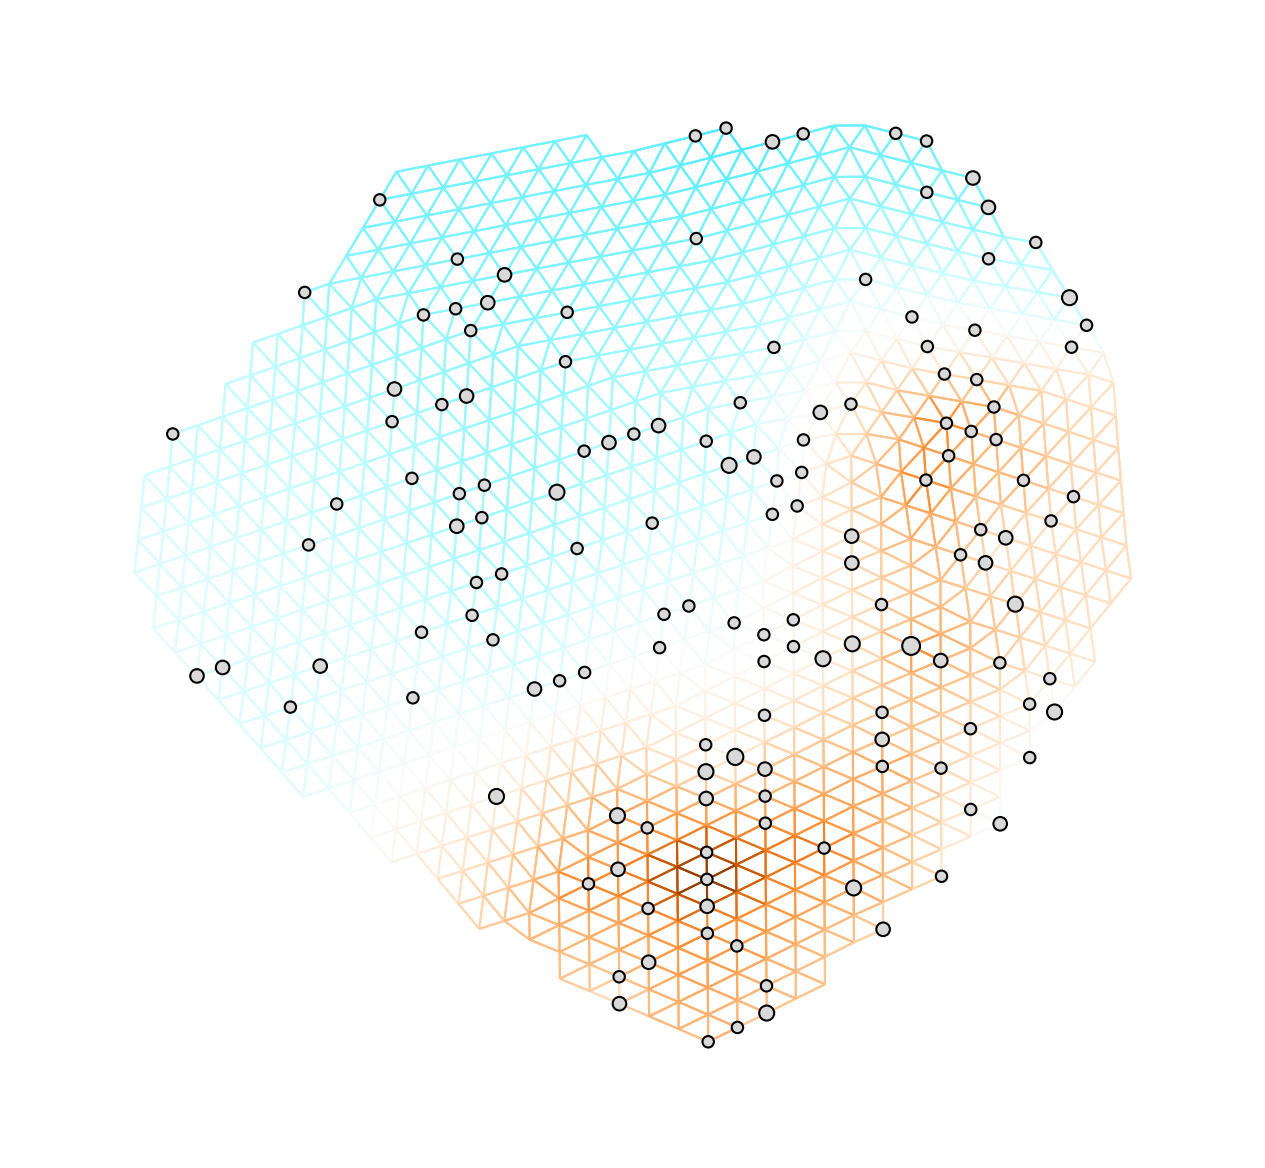

In [5]:
def com_feems(genos, mac=0):
    maf_mask = genos.sum(axis=0) < mac
    genos = genos[:, ~maf_mask]
    print(f"sites:{genos.shape[0]} - species:{genos.shape[1]}")
    
    outer, edges, grid, _ = prepare_graph_inputs(coord=coords, ggrid=grid_path, translated=False, buffer=0, outer=hdm_outer)
    sp_graph = SpatialGraph(genos, coords, grid, edges, scale_snps=False)
    sp_graph.fit(lamb=10.0)
    
    fig = plt.figure(dpi=300) 
    
    projection = ccrs.EquidistantConic(central_longitude=100.6897, central_latitude=30.7702)
    # Use PlateCarree to Match EPSG:4326
    # projection = ccrs.PlateCarree(central_longitude=100.6897) 
    
    ax = fig.add_subplot(1, 1, 1, projection=projection) 
    v = Viz(ax, sp_graph, projection=projection, edge_width=0.5, 
        edge_alpha=1, edge_zorder=100, sample_pt_size=20, 
        obs_node_size=7.5, sample_pt_color="black", 
        cbar_font_size=10, abs_max=0.5) 
    #v.draw_map() 
    v.draw_edges(use_weights=True) 
    v.draw_obs_nodes(use_ids=False)
    
    fig.savefig(f"../figures/community_feems/community-feems-mac{mac}.png")
    np.save(f"../data/community_feems/community-feems-edge-weights-mac{mac}", sp_graph.w)
    return sp_graph

# We need to save the sp_graph for later for replacing the weights and replotting
sp_graph = com_feems(genos, mac=0)
community_w = sp_graph.w

In [ ]:
comm_wts = {}
for mac in [0, 2, 4, 10, 20]:
    print(f"Doing mac: {mac}")
    comm_wts[mac] = com_feems(genos, mac=mac)

In [1]:
community_w

NameError: name 'community_w' is not defined

## Load the FEEMS migration matrices from the phylogeography dataset

In [72]:
feems_output_files = PHYLOGEO_FEEMS_DIR / "pedic_feems_output/"
weights = {f.rsplit("/", 1)[1].split("_")[0]:np.load(f) for f in glob.glob(str(feems_output_files) + "/*_edges.npy")}
weights

{'szet': array([1.96034051, 1.91568056, 1.94410258, ..., 0.39449167, 0.39430681,
        0.39147464]),
 'crano': array([10.0541342 ,  9.75833707,  9.93254099, ...,  8.15850619,
         8.21337726,  8.05435637]),
 'vert': array([1.91804424, 1.91454763, 1.91679555, ..., 0.50220995, 0.4821391 ,
        0.53938061]),
 'lachno': array([4.36885695, 4.38480797, 4.37370606, ..., 2.0942731 , 2.09430897,
        2.09268146]),
 'anas': array([1.36743709, 1.32884885, 1.35353335, ..., 0.61095908, 0.58478231,
        0.66535405]),
 'densis': array([3.95824764, 3.9541347 , 3.95720351, ..., 2.7248903 , 2.6587156 ,
        2.83411883]),
 'tenu': array([4.33510452, 4.23613048, 4.30054994, ..., 0.02385023, 0.02354401,
        0.02438524]),
 'longi': array([5.06208817, 4.78003967, 4.8622194 , ..., 0.33341099, 0.31777762,
        0.36485921]),
 'brevi': array([17.83066299, 17.73906479, 17.80548766, ...,  6.25850825,
         6.22444588,  6.31824587]),
 'integ': array([1.20841686, 1.18634987, 1.19794583, .

## A function to replace the weights with a FEEMS SpatialGraph and then plot

In [87]:
# Hack the sp_graph with new weights
def plot_weights(wt, log_edges=True, label=None, outfile=None, ax=None, outdir=None, savefig=True, plot_rivers=True):
    # Hack the edge weights in the spatial graph with stacked weights
    sp_graph.w = wt
    projection = ccrs.EquidistantConic(central_longitude=100.6897, central_latitude=30.7702)
    if not ax:
        fig = plt.figure(dpi=300) 
        ax = fig.add_subplot(1, 1, 1, projection=projection)
    else:
        fig = ax.get_figure()
        # ax passed in so don't try to save the figure, allow parent caller to do it

    # From feems.viz, this is how it norms the weights internally, so we do this here
    # to find a reasonable value for abs_max
    if log_edges:
        norm_log_weights = np.log10(wt) - np.mean(np.log10(wt))
        abs_max = max(abs(norm_log_weights.min()), 
                      abs(norm_log_weights.max()))
        edge_vmin = norm_log_weights.min()
        edge_vmax = norm_log_weights.max()
    else:
        abs_max = 1
        edge_vmin = -1
        edge_vmax = 1

    ax.set_title(label)
    v = Viz(ax,
            sp_graph,
            projection=projection,
            edge_width=.5,
            edge_alpha=1,
            edge_zorder=100,
            sample_pt_size=0, 
            obs_node_size=0,
            sample_pt_color="black",
            #weights=weights[0],
            cbar_font_size=10,
            abs_max=abs_max,
           )

#    if log_edges == False:
#        v.edge_cmap = matplotlib.colormaps["Blues"]

    if plot_rivers:
        global rivers
        if not isinstance(rivers, gpd.GeoDataFrame):
            print("  Loading river data and clipping to bounds")
            rivers = prep_river_data(ax)
        rivers.plot(ax=ax, color="blue", lw=rivers["LW_DIST_UP_KM"] * 10, edgecolor="face", alpha=0.75);
    
    #v.draw_map() <- This doesn't do anything but make the background grey because we are zoomed in too far
    v.draw_edges(use_weights=True,
                edge_vmin=edge_vmin,
                edge_vmax=edge_vmax) 
    v.draw_obs_nodes(use_ids=False)

    cx.add_basemap(ax, source=cx.providers.USGS.USTopo)
    
    outfile = label
    if outfile and savefig:
        fig.savefig(str(outdir) + f"/{outfile}.png")
        np.save(str(outdir) + f"/{outfile}.npy", wt)

    return ax


def plot_weights_map(wt, ax=None, title=None, outfile=None, edge_norm=False, 
                     plot_rivers=True, figsize=(20,20), savefig=False):

    if edge_norm:
        wt = np.log10(wt) - np.mean(np.log10(wt))
    
    ## Format nx nodes/edges to gpd and inject edge weights
    nodes = []
    def pos_to_latlong(data):
        # Function to pull latlongs out of nx node pos
        return [float(x) for x in data["pos"][1:-1].split()]
            
    for node, data in g.nodes(data=True):
        # Pull the 'pos' info out of the data, munge it and convert to a tuple of floats
        pos = pos_to_latlong(data)
        point = Point(pos[0], pos[1])  # lon, lat for geometry
        nodes.append({'id': node, 'geometry': point})
    
    gdf_nodes = gpd.GeoDataFrame(nodes, crs="EPSG:4326")
    
    # Enumerate edges and add edge weights from feems as an edge property
    edges = []
    for idx, (u, v, data) in enumerate(g.edges(data=True)):
        point_u = Point(pos_to_latlong(g.nodes[u]))
        point_v = Point(pos_to_latlong(g.nodes[v]))
        edges.append({
            'source': u,
            'target': v,
            'weight': wt[idx],
            'geometry': LineString([point_u, point_v])
        })
    
    gdf_edges = gpd.GeoDataFrame(edges, crs="EPSG:4326")

    ## Plot gpd nodes/edges on map
    
    # Project to Web Mercator for basemap compatibility
    gdf_nodes_web = gdf_nodes.to_crs(epsg=3857)
    gdf_edges_web = gdf_edges.to_crs(epsg=3857)

    if not ax:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
    #gdf_nodes_web.plot(ax=ax, color='black', markersize=5)

    # If saving the figure make the rivers and edges bigger
    if savefig:
        lw_river = 10
        lw_edges = 2
    else:
        lw_river = 5
        lw_edges = 0.65

    if plot_rivers:
        global rivers
        if not isinstance(rivers, gpd.GeoDataFrame):
            print("  Loading river data and clipping to bounds")
            rivers = prep_river_data(ax)
        rivers.plot(ax=ax, color="blue", lw=rivers["LW_DIST_UP_KM"] * lw_river, edgecolor="face", alpha=0.75);

    gdf_edges_web.plot(
        ax=ax,
        column='weight',
        cmap=edge_cmap,
        linewidth=lw_edges,
        legend=False
    )
    
    # Add basemap, with a few reasonable alternatives listed here
    # Alt: Esri.WorldTopoMap
    # Alt: Esri.WorldImagery
    # Alt: Esri.WorldTerrain
    # Alt: Esri.WorldShadedRelief
    
    # Alt: USGS.USTopo
    cx.add_basemap(ax, source=cx.providers.USGS.USTopo, attribution=False)
    
    ax.set_title(title)
    ax.set_axis_off()

    if outfile and savefig:
        fig.savefig(outfile)
        np.save(str(outfile).rsplit(".", 1)[0]+".npy", wt)
    return ax

# Helper function for loading/formatting the river data
def prep_river_data(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    bbox = (xmin, ymin, xmax, ymax)
    bbox = Polygon([
        (xmin, ymin),
        (xmin, ymax), 
        (xmax, ymax),
        (xmax, ymin),
    ])
    
    # load as geodataframe
    rivers = gpd.read_file(rivers_file).to_crs("EPSG:3857").clip(bbox)
    
    # keep only big rivers (up to ORD_FLOW 8 also looks good)
    rivers = rivers.loc[rivers["ORD_FLOW"] < 6]
    
    # scale river sizes for visualization based on dist up
    left_span = np.amax(rivers["DIST_UP_KM"]) - np.amin(rivers["DIST_UP_KM"])
    right_span = 0.6 - 0.005
    value_scaled = (rivers["DIST_UP_KM"] - np.amin(rivers["DIST_UP_KM"])) / left_span
    rivers.loc[:, "LW_DIST_UP_KM"] = 0.005 + (value_scaled * right_span)
    return rivers

## A function to do the 'diff' between the community and popgen FEEMS matrices

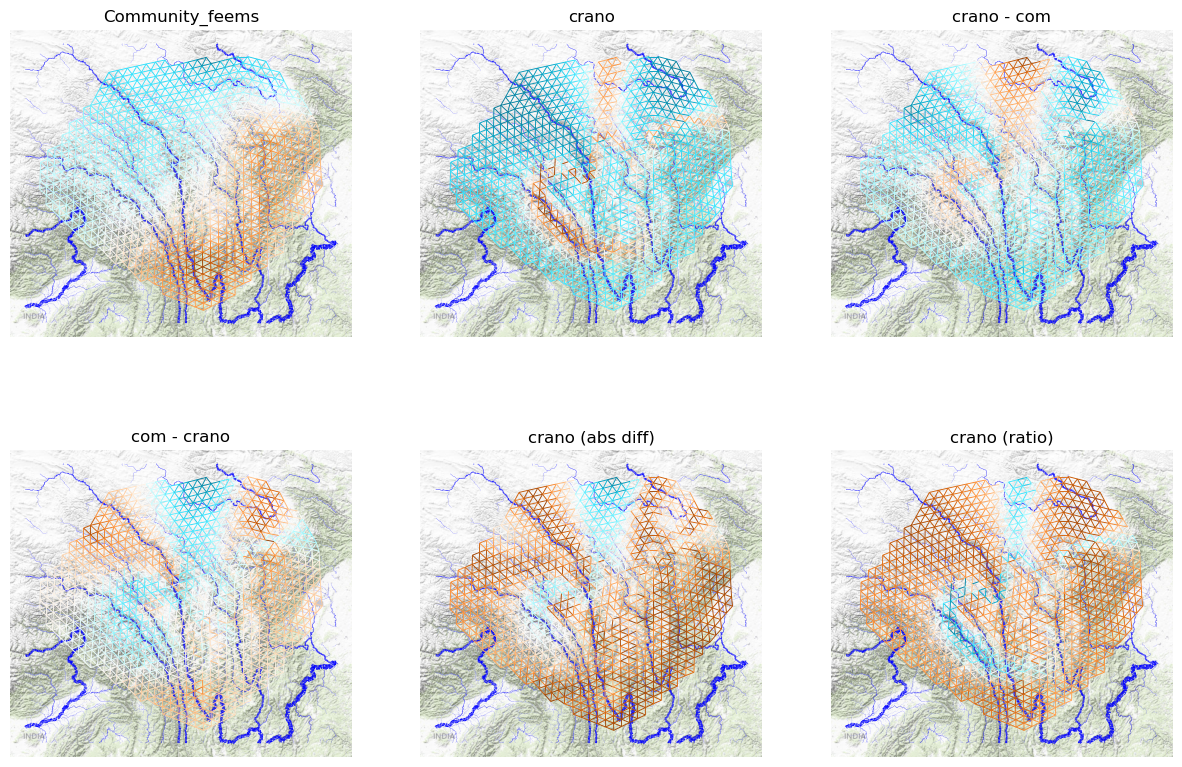

In [89]:
## Rescale both weight matrices to unit interval
def scale(w1, w2):
    w1 = (w1 - w1.min()) / w1.max()
    w2 = (w2 - w2.min()) / w2.max()    
    return w1, w2

def plot_com_popgen_feems_diffs(comm_feems, popgen_feems, sp, multi_panel=False):

    w1, w2 = scale(comm_feems, popgen_feems)
    
    # Community minus species.
    wt = w1 - w2
    # Shift values to strictly positive
    com_minus_sp = wt + np.abs(wt.min() * 2)
    
    # Species minus community
    wt = w2 - w1
    sp_minus_com = wt + np.abs(wt.min() * 2)
    
    # Absolute value of the difference
    abs_difference = np.abs(w2 - w1)

    # Absolute Log ratio
    A = comm_feems
    B = popgen_feems
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = A / B
        inv_ratio = B / A
        diff = np.where((A > 0) & (B > 0), np.maximum(ratio, inv_ratio), 0)

    if multi_panel == False:
        axs = [None] * 6
        savefig = True
    else:
        fig, ax = plt.subplots(2, 3, figsize=(15, 10))
        axs = [item for sublist in ax for item in sublist]
        savefig = False

    OUTDIR = Path("../figures/community_feems")
    # This is the old way that plots the weights w/o geography
    #ax1 = plot_weights(comm_feems, ax=axs[0], log_edges=False, outdir=OUTDIR, label="Community_feems", savefig=savefig)
    #ax2 = plot_weights(popgen_feems, ax=axs[1], log_edges=False, outdir=OUTDIR / 'species_feems/', label=sp, savefig=savefig)
    #ax4 = plot_weights(sp_minus_com, ax=axs[2], log_edges=True, outdir=OUTDIR / 'sp-com/', label=f"{sp} - com", savefig=savefig)
    #ax3 = plot_weights(com_minus_sp, ax=axs[3], outdir=OUTDIR / 'com-sp/', label=f"com - {sp}", savefig=savefig)
    #ax5 = plot_weights(abs_difference, ax=axs[4], log_edges=False, outdir=OUTDIR / 'abs/', label=f"{sp} (abs diff)", savefig=savefig)
    #ax6 = plot_weights(diff, ax=axs[5], log_edges=False, outdir=OUTDIR / 'ratio/', label=f"{sp} (ratio)", savefig=savefig)

    outfile = OUTDIR / "Community_feems.png"
    ax1 = plot_weights_map(comm_feems, ax=axs[0], edge_norm=False, outfile=str(outfile), title="Community_feems", savefig=savefig)
    ax2 = plot_weights_map(popgen_feems, ax=axs[1], edge_norm=True, title=sp, savefig=savefig)
    outfile = OUTDIR / f"sp-com/{sp} - com.png"
    ax4 = plot_weights_map(sp_minus_com, ax=axs[2], edge_norm=True, outfile=str(outfile), title=f"{sp} - com", savefig=savefig)
    outfile = OUTDIR / f"com-sp/com - {sp}.png"
    ax3 = plot_weights_map(com_minus_sp, ax=axs[3], outfile=outfile, title=f"com - {sp}", savefig=savefig)
    outfile = OUTDIR / f"abs/{sp} (abs diff).png"
    ax5 = plot_weights_map(abs_difference, ax=axs[4], edge_norm=False, outfile=outfile, title=f"{sp} (abs diff)", savefig=savefig)
    outfile = OUTDIR / f"ratio/{sp} (ratio).png"
    ax6 = plot_weights_map(diff, ax=axs[5], edge_norm=True, outfile=outfile, title=f"{sp} (ratio)", savefig=savefig)

    if multi_panel == True:
        fig.savefig(f"../figures/community_feems/multipanel/{sp}-combined.png")

sp = 'crano'
plot_com_popgen_feems_diffs(community_w, weights[sp], sp, multi_panel=True)


In [ ]:
## Do all multipanel
for sp, wt in weights.items():
    print(f"Doing {sp}")
    plot_com_popgen_feems_diffs(community_w, wt, sp, multi_panel=True)


In [ ]:
# Do all single panel
for sp, wt in weights.items():
    print(f"Doing {sp}")
    plot_com_popgen_feems_diffs(community_w, wt, sp, multi_panel=False)

## Comm feems diff with popgen stacked feems mean/entropy

In [ ]:
popgen_feems_mean = np.load("/Users/isaac/proj/phylogeo-feems/pedic_feems_output/pedic_feems_stacked_figures/stacked_scaled_mean.npy")
popgen_feems_entropy = np.load("/Users/isaac/proj/phylogeo-feems/pedic_feems_output/pedic_feems_stacked_figures/stacked_raw_entropy.npy")

plot_com_popgen_feems_diffs(community_w, popgen_feems_mean, "popgen_mean", multi_panel=False)
plot_com_popgen_feems_diffs(community_w, popgen_feems_entropy, "popgen_entropy", multi_panel=False)

# Ignore

(array([272., 438., 467., 425., 379., 288., 157.,  17.,   8.,   4.]),
 array([2.02224604e-04, 7.52139761e-02, 1.50225728e-01, 2.25237479e-01,
        3.00249231e-01, 3.75260982e-01, 4.50272734e-01, 5.25284485e-01,
        6.00296237e-01, 6.75307988e-01, 7.50319740e-01]),
 <BarContainer object of 10 artists>)

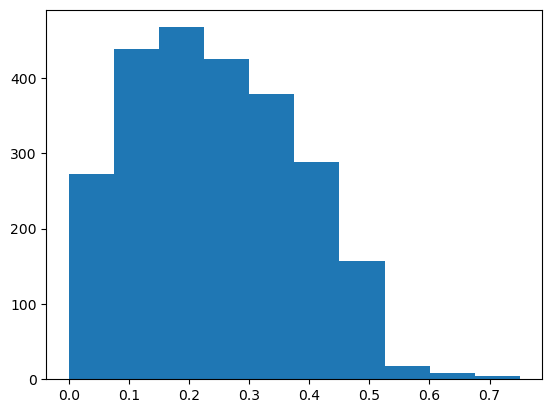

In [243]:
plt.hist(wts)

(208, 321)
[  1  35   4  18   1  72   4   5   7   1   7  21   3   1   1   5  51  16
   4  10   3   2   5   0   4   0  29  28   9   1  36   6  26   1   1   2
  12   0  16  50   2   6   1 104   1   6   1  17  28   9   2  39   9   1
   8   8  49  11  22  14  39   8  69   1  15   3   2   8   3   2  15   7
   1   0   7   1   9   2  48   4   5   7   6   5  10   2   3   6   1  15
   1   2   3   5   2   3   0   5   3   1   2  36   4  16  10   1   5  14
   5   1   1   0   3   1   3   0   3  42   2  64   2 104   1   4   2   1
  12  90   1   1   3   1  27   2  14   4   2   1   4   2   2  23   1  32
   1   2   2 116   4   8   8   1   1  33  42   4   3  41   1   2   6   3
   3  10   8   8  13   0   0  15   1   7   3   4  11  12   7   0  11   7
  27   2   0   1   5   0   1   5   1   4   1   0  67   0  23   9   1  29
   6   1   2   0  11   2  13   7   6   1   1   0  29   1  35  10   1   7
  44   6   2  10  41   6   7   7   3   2   2   2   1   5   8  72  99   4
  42   2  14   9   3   3   5   1   1   1

(array([32., 69., 62., 21., 10.,  8.,  2.,  1.,  1.,  2.]),
 array([ 3. ,  9.2, 15.4, 21.6, 27.8, 34. , 40.2, 46.4, 52.6, 58.8, 65. ]),
 <BarContainer object of 10 artists>)

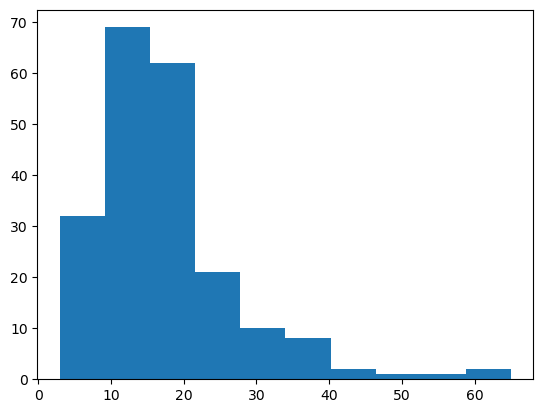

In [336]:
print(genos.shape)
print(genos.sum(axis=0))
print(genos.sum(axis=1))
plt.hist(genos.sum(axis=1))

## FEEMS CV
Best lambda from CV is 10

In [38]:
%%time
# define grids
# reverse the order of lambdas and alphas for warmstart
lamb_grid = np.geomspace(1e-6, 1e2, 10)[::-1]

# Slight hack to work around divide by zero error
tmp_genos = genos + 1

sp_graph = SpatialGraph(tmp_genos, coords, grid, edges, scale_snps=True)

# run cross-validation
cv_err = run_cv(sp_graph, lamb_grid, n_folds=20, factr=1e10)

# average over folds
mean_cv_err = np.mean(cv_err, axis=0)

# argmin of cv error
lamb_cv = float(lamb_grid[np.argmin(mean_cv_err)])


 fold= 0
iteration lambda=10/10 alpha=1/1
 fold= 1
iteration lambda=10/10 alpha=1/1
 fold= 2
iteration lambda=10/10 alpha=1/1
 fold= 3
iteration lambda=10/10 alpha=1/1
 fold= 4
iteration lambda=10/10 alpha=1/1
 fold= 5
iteration lambda=10/10 alpha=1/1
 fold= 6
iteration lambda=10/10 alpha=1/1
 fold= 7
iteration lambda=10/10 alpha=1/1
 fold= 8
iteration lambda=10/10 alpha=1/1
 fold= 9
iteration lambda=10/10 alpha=1/1
 fold= 10
iteration lambda=10/10 alpha=1/1
 fold= 11
iteration lambda=10/10 alpha=1/1
 fold= 12
iteration lambda=10/10 alpha=1/1
 fold= 13
iteration lambda=10/10 alpha=1/1
 fold= 14
iteration lambda=10/10 alpha=1/1
 fold= 15
iteration lambda=10/10 alpha=1/1
 fold= 16
iteration lambda=10/10 alpha=1/1
 fold= 17
iteration lambda=10/10 alpha=1/1
 fold= 18
iteration lambda=10/10 alpha=1/1
 fold= 19
iteration lambda=10/10 alpha=1/1CPU times: user 15min 25s, sys: 1min 51s, total: 17min 16s
Wall time: 2min 11s


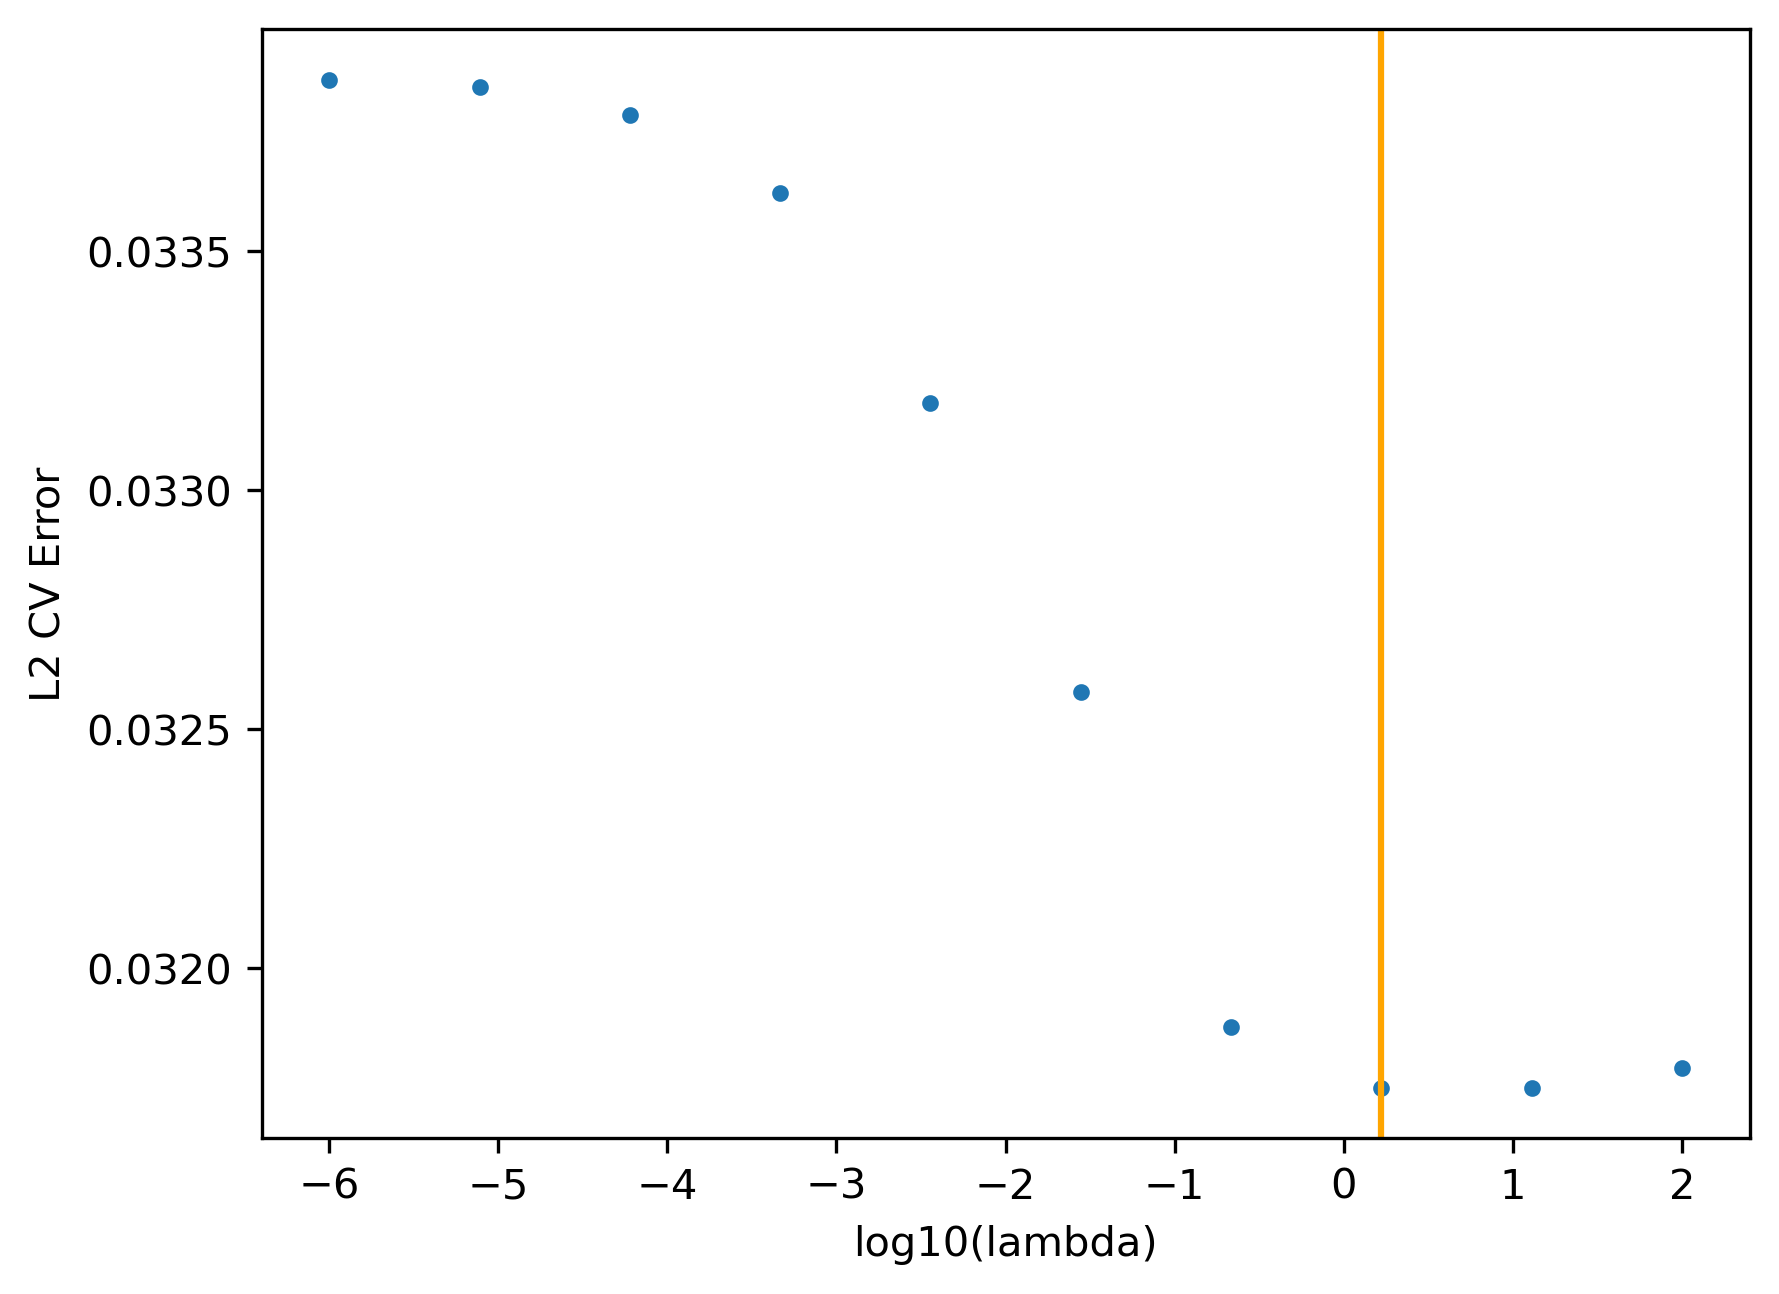

In [39]:
fig, ax = plt.subplots(dpi=300)
ax.plot(np.log10(lamb_grid), mean_cv_err, ".");
ax.set_xlabel("log10(lambda)");
ax.set_ylabel("L2 CV Error");
ax.axvline(np.log10(lamb_cv), color = "orange")

In [234]:
"trimmed-Asgard_WA_C_LAR" == "trimmed-Asgard_WA_C_LAR"


True